In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [ ]:
#1 load dataset
df= pd.read_csv('train.csv')

print("Dataset Shape:", df.shape)
print(df.info())
print(df.describe())
    

Dataset Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000  

In [ ]:
#2 data preprocessing
print("Missing Values:\n", df.isnull().sum())

#encoder gender if nedeed
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
#select features for clustering 
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
#scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


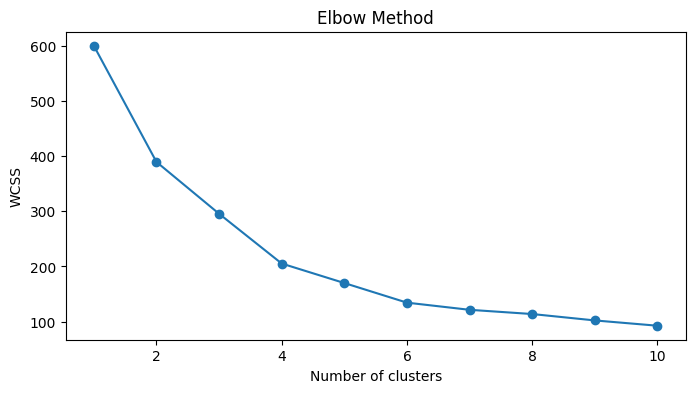

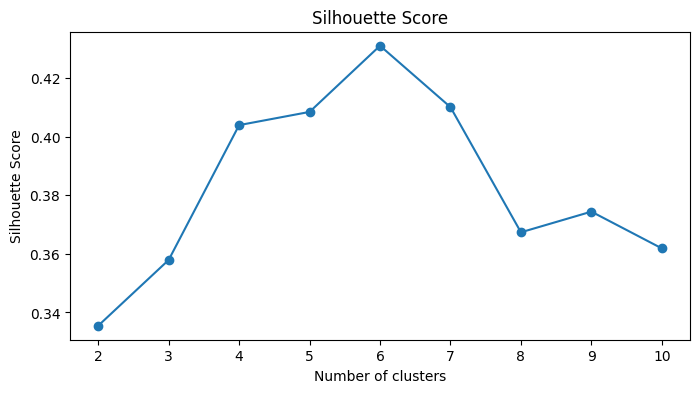

In [ ]:
#3 find optimal clusters using elbow method
wcss = []   
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#4 find optimal clusters using silhouette score   
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, cluster_labels))
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [ ]:
#5 Model Training 
optimal_k = 5 

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters

In [8]:
# 6. Cluster Analysis
cluster_summary = df.groupby('Cluster').mean()
print("Cluster Summary:\n", cluster_summary)

Cluster Summary:
          CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         24.100000  0.600000  46.250000           26.750000   
1         55.648148  0.592593  25.185185           41.092593   
2        161.025000  0.550000  32.875000           86.100000   
3        159.743590  0.487179  39.871795           86.102564   
4         83.872340  0.574468  55.638298           54.382979   

         Spending Score (1-100)  
Cluster                          
0                     18.350000  
1                     62.240741  
2                     81.525000  
3                     19.358974  
4                     48.851064  


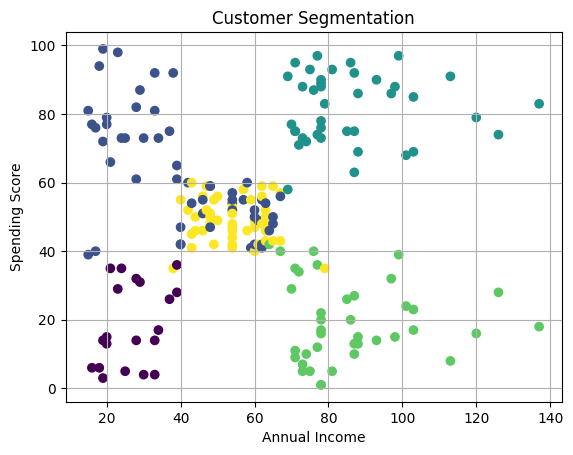

In [ ]:
# 7. Visualization
plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
            c=clusters)
plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid()
plt.show()

In [10]:
# 8. Save Results
df.to_csv("Final_Customer_Segments.csv", index=False)


In [13]:
# 9. Insights Generation

for i in range(optimal_k):
    print(f"\nCluster {i} Analysis:")
    cluster_data = df[df['Cluster'] == i]
    print("Count:", len(cluster_data))
    print("Average Age:", cluster_data['Age'].mean())
    print("Average Annual Income:", cluster_data['Annual Income (k$)'].mean())
    print("Average Spending Score:", cluster_data['Spending Score (1-100)'].mean())
    


Cluster 0 Analysis:
Count: 20
Average Age: 46.25
Average Annual Income: 26.75
Average Spending Score: 18.35

Cluster 1 Analysis:
Count: 54
Average Age: 25.185185185185187
Average Annual Income: 41.092592592592595
Average Spending Score: 62.24074074074074

Cluster 2 Analysis:
Count: 40
Average Age: 32.875
Average Annual Income: 86.1
Average Spending Score: 81.525

Cluster 3 Analysis:
Count: 39
Average Age: 39.87179487179487
Average Annual Income: 86.1025641025641
Average Spending Score: 19.358974358974358

Cluster 4 Analysis:
Count: 47
Average Age: 55.638297872340424
Average Annual Income: 54.38297872340426
Average Spending Score: 48.851063829787236
